Basic Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   70692 non-null  float64
 1   Sex                   70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   HeartDiseaseorAttack  70692 non-null  float64
 7   PhysActivity          70692 non-null  float64
 8   Fruits                70692 non-null  float64
 9   Veggies               70692 non-null  float64
 10  HvyAlcoholConsump     70692 non-null  float64
 11  GenHlth               70692 non-null  float64
 12  MentHlth              70692 non-null  float64
 13  PhysHlth              70692 non-null  float64
 14  DiffWalk              70692 non-null  float64
 15  Stroke  

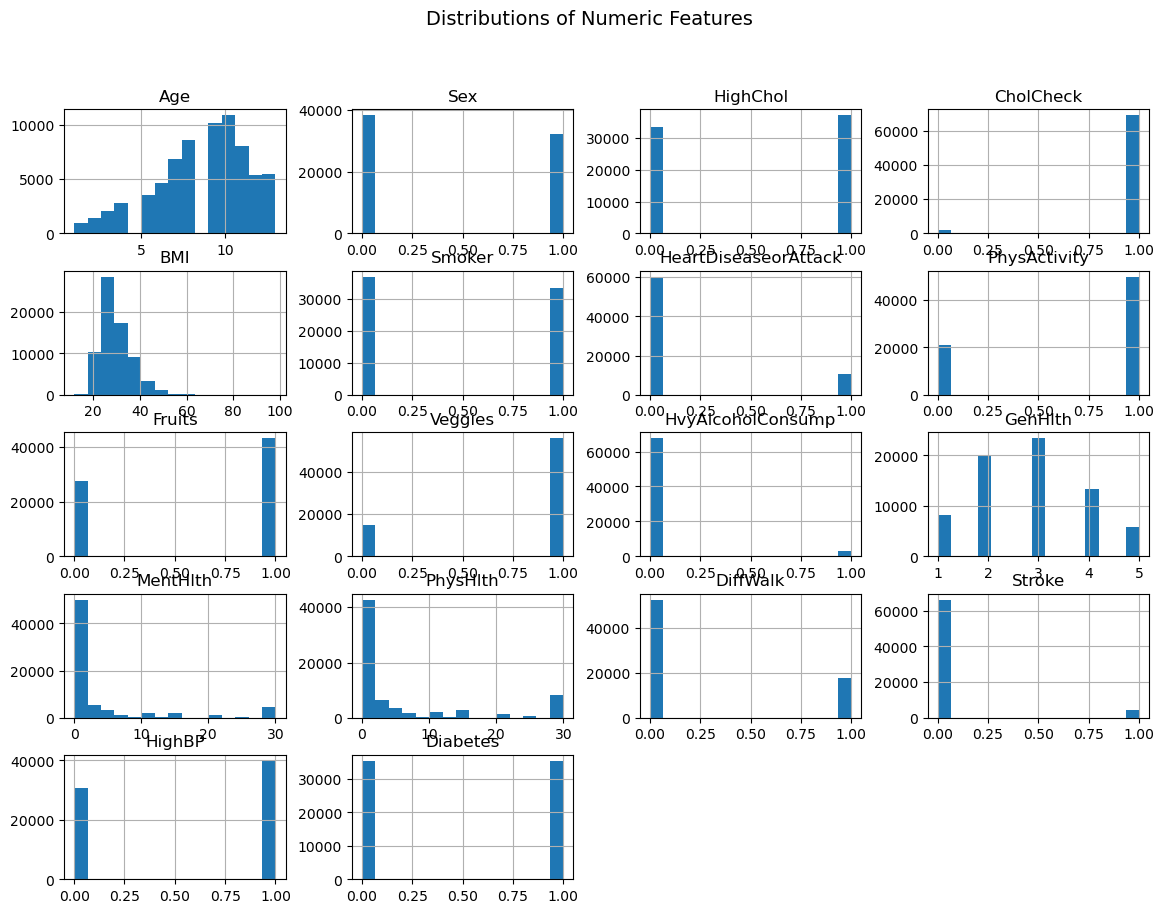

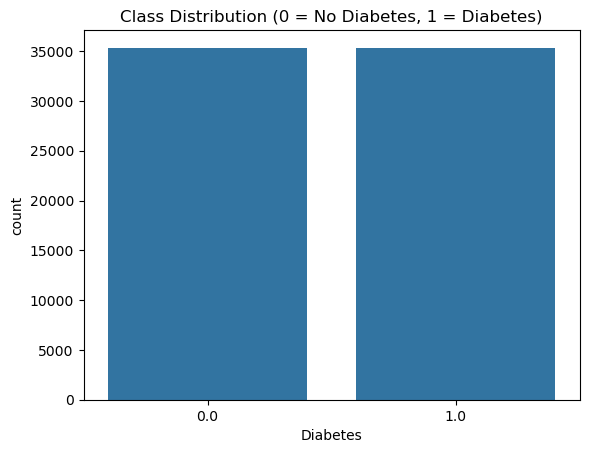

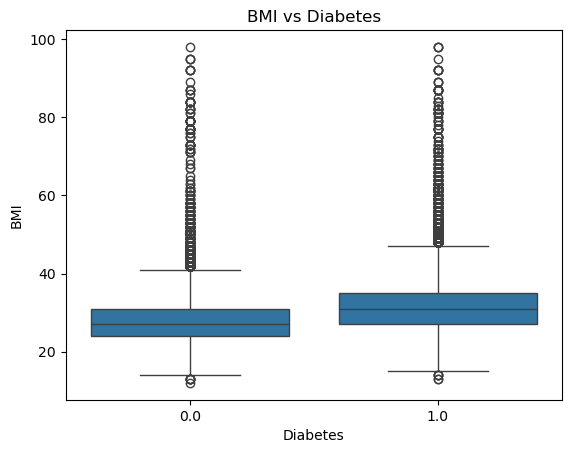

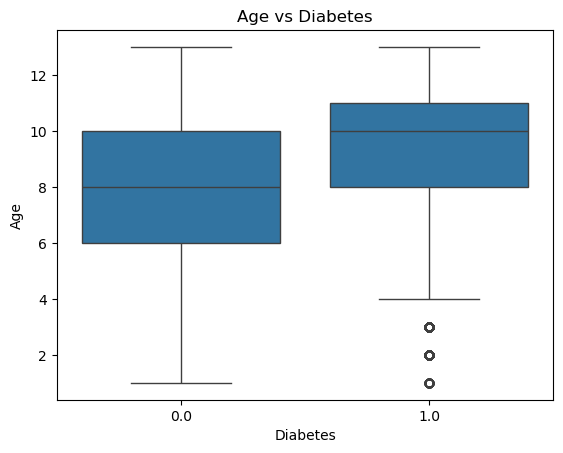



 Missing Values 
No missing values detected.


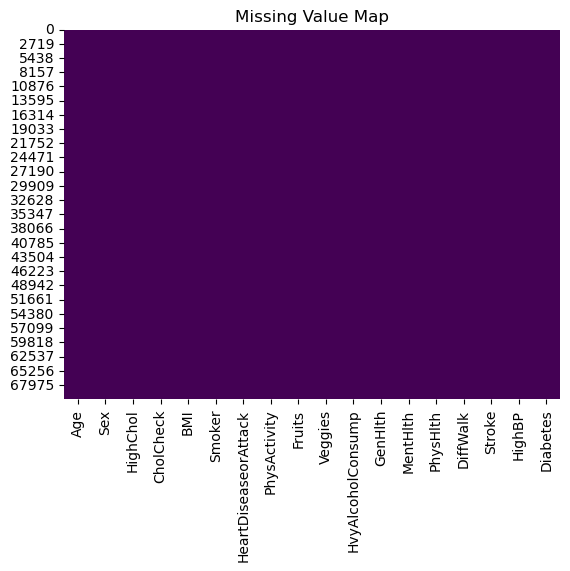



 Correlation Matrix 
Diabetes                1.000000
GenHlth                 0.407612
HighBP                  0.381516
BMI                     0.293373
HighChol                0.289213
Age                     0.278738
DiffWalk                0.272646
PhysHlth                0.213081
HeartDiseaseorAttack    0.211523
Stroke                  0.125427
CholCheck               0.115382
MentHlth                0.087029
Smoker                  0.085999
Sex                     0.044413
Fruits                 -0.054077
Veggies                -0.079293
HvyAlcoholConsump      -0.094853
PhysActivity           -0.158666
Name: Diabetes, dtype: float64


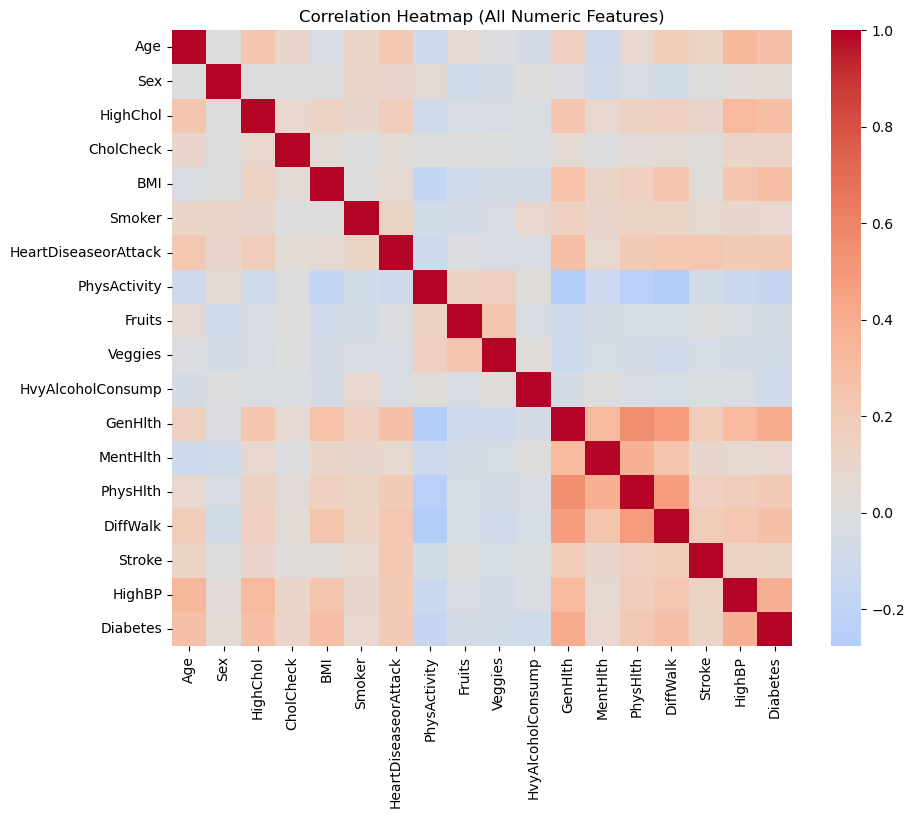

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("diabetes_data.csv")

# check pattrns if they exist
print("Basic Info")
print(df.info())              # data types, null count, etc.
print("\nBasic Statistics")
print(df.describe())          # mean, std, min, max, etc.

# Visualize a few distributions
num_cols = df.select_dtypes(include=["float64", "int64"]).columns

df[num_cols].hist(figsize=(14, 10), bins=15)
plt.suptitle("Distributions of Numeric Features", fontsize=14)
plt.show()

# Check how Diabetes relates to some key features
sns.countplot(x="Diabetes", data=df)
plt.title("Class Distribution (0 = No Diabetes, 1 = Diabetes)")
plt.show()

sns.boxplot(x="Diabetes", y="BMI", data=df)
plt.title("BMI vs Diabetes")
plt.show()

sns.boxplot(x="Diabetes", y="Age", data=df)
plt.title("Age vs Diabetes")
plt.show()


#Look for missing values
print("\n\n Missing Values ")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values detected.")

# Visualize missing values (if any)
sns.heatmap(df.isnull(), cbar=False, cmap="viridis")
plt.title("Missing Value Map")
plt.show()


# Make correlations
print("\n\n Correlation Matrix ")
corr = df.corr(numeric_only=True)
print(corr["Diabetes"].sort_values(ascending=False))

# Heatmap for visual overview
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (All Numeric Features)")
plt.show()


In [3]:
# Preprocessing the data

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

#  separate features from target

target_col = "Diabetes"
X = df.drop(columns=[target_col])
y = df[target_col].astype(int)

# check and clean the data

# missing values?
print("Missing values per column:")
print(X.isnull().sum())

# handle missing numeric values
imputer = SimpleImputer(strategy="median")
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# scale the features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_imputed), columns=X.columns)

# split train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("\n Data preprocessing is complete")
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)
print("Scaled feature sample:\n", X_train.head())


Missing values per column:
Age                     0
Sex                     0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Stroke                  0
HighBP                  0
dtype: int64

 Data preprocessing is complete
Training set: (56553, 17)
Test set: (14139, 17)
Scaled feature sample:
             Age       Sex  HighChol  CholCheck       BMI    Smoker  \
47977  0.496451  1.090046 -1.052798   0.159276 -0.120466  1.050740   
2676  -0.555393 -0.917392  0.949850   0.159276 -0.823315  1.050740   
35637  0.847066 -0.917392 -1.052798   0.159276  1.706941  1.050740   
52420  0.496451 -0.917392  0.949850   0.159276  0.020104 -0.951711   
12445 -0.906008  1.090046 -1.052798   0.159276  0.722953  1.050